In [1]:
# %load ini.py
# 导入三大神器
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
# 解决字体mac
plt.rcParams['font.sans-serif'] = ['SimHei']  
# 解决负号显示问题
plt.rcParams['axes.unicode_minus'] = False

In [14]:
#读取数据
df = pd.read_csv('共享单车_清洗后.csv')
# 将时间字段转为datetime格式
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# 提取日期（用于后续分组）
df['start_date'] = df['start_time'].dt.date

# 查看前几行确认
df.head()

,orderid,bikeid,userid,start_time,start_location_x(°),start_location_y(°),end_time,end_location_x(°),end_location_y(°),track,...,time_period,is_weekend,ride_date,天气,avg_temp(℃),sunshine_h(h),max_temp(℃),min_temp(℃),actual_temp(℃),start_date
0,78387,158357,10080,2016-08-20 06:57:00,121.348,31.389,2016-08-20 07:04:00,121.357,31.388,"121.347,31.392#121.348,31.389#121.349,31.390#1...",...,早高峰(6-9点),1,2016-08-20,晴,31.0,11.9,33.8,28.1,28.1,2016-08-20
1,891333,92776,6605,2016-08-29 19:09:00,121.508,31.279,2016-08-29 19:31:00,121.489,31.271,"121.489,31.270#121.489,31.271#121.490,31.270#1...",...,晚高峰(17-20点),0,2016-08-29,晴,25.2,12.0,29.5,21.0,25.2,2016-08-29
2,1106623,152045,8876,2016-08-13 16:17:00,121.383,31.254,2016-08-13 16:36:00,121.405,31.248,"121.381,31.251#121.382,31.251#121.382,31.252#1...",...,日间(9-17点),1,2016-08-13,晴,29.6,12.0,31.9,27.4,31.9,2016-08-13
3,1389484,196259,10648,2016-08-23 21:34:00,121.484,31.320,2016-08-23 21:43:00,121.471,31.325,"121.471,31.325#121.472,31.325#121.473,31.324#1...",...,夜间(20-6点),0,2016-08-23,晴,28.9,11.9,31.6,26.2,26.2,2016-08-23
4,188537,78208,11735,2016-08-16 07:32:00,121.407,31.292,2016-08-16 07:41:00,121.418,31.288,"121.407,31.291#121.407,31.292#121.408,31.291#1...",...,早高峰(6-9点),0,2016-08-16,晴,29.2,12.0,31.8,26.6,29.2,2016-08-16


## B3 天气影响分析

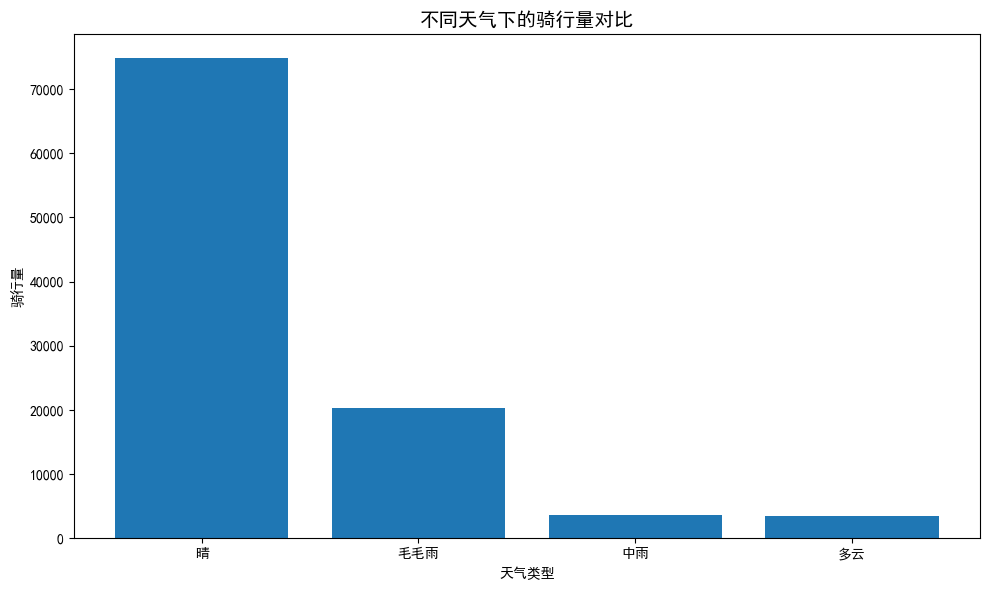

In [20]:
#不同天气的骑行量   晴/雨/阴天差异多大？  柱状图
# 统计每种天气的骑行量
weather_counts = df['天气'].value_counts()
# 绘制柱状图
plt.figure(figsize=(10,6))
bars = plt.bar(weather_counts.index, 
               weather_counts.values
)
plt.title('不同天气下的骑行量对比', fontsize=14)
plt.xlabel('天气类型')
plt.ylabel('骑行量')
plt.tight_layout()
plt.show()

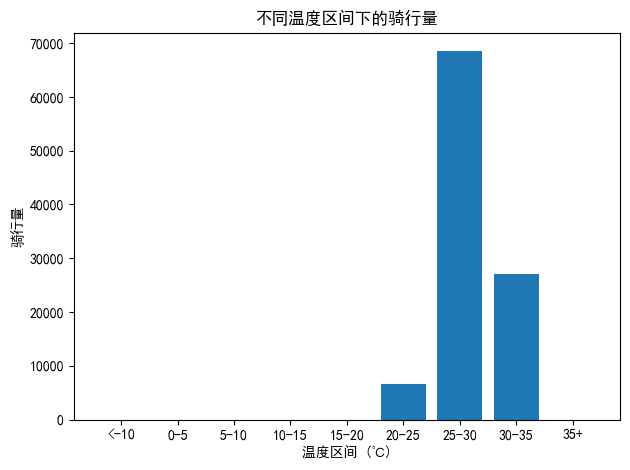

In [32]:
# 创建温度区间（分组）
# 使用实际温度 actual_temp(℃)
bins = [-10, 0, 5, 10, 15, 20, 25, 30, 35, 45]
labels = ['<-10', '0-5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35+']
df['temp_range'] = pd.cut(df['actual_temp(℃)'], bins=bins, labels=labels, right=False)

# 统计每个温度区间的骑行量
temp_riding = df['temp_range'].value_counts().sort_index()

# 绘制分组柱状图
bars = plt.bar(temp_riding.index.astype(str), temp_riding.values)
plt.title('不同温度区间下的骑行量')
plt.xlabel('温度区间 (℃)')
plt.ylabel('骑行量')
plt.tight_layout()
plt.show()

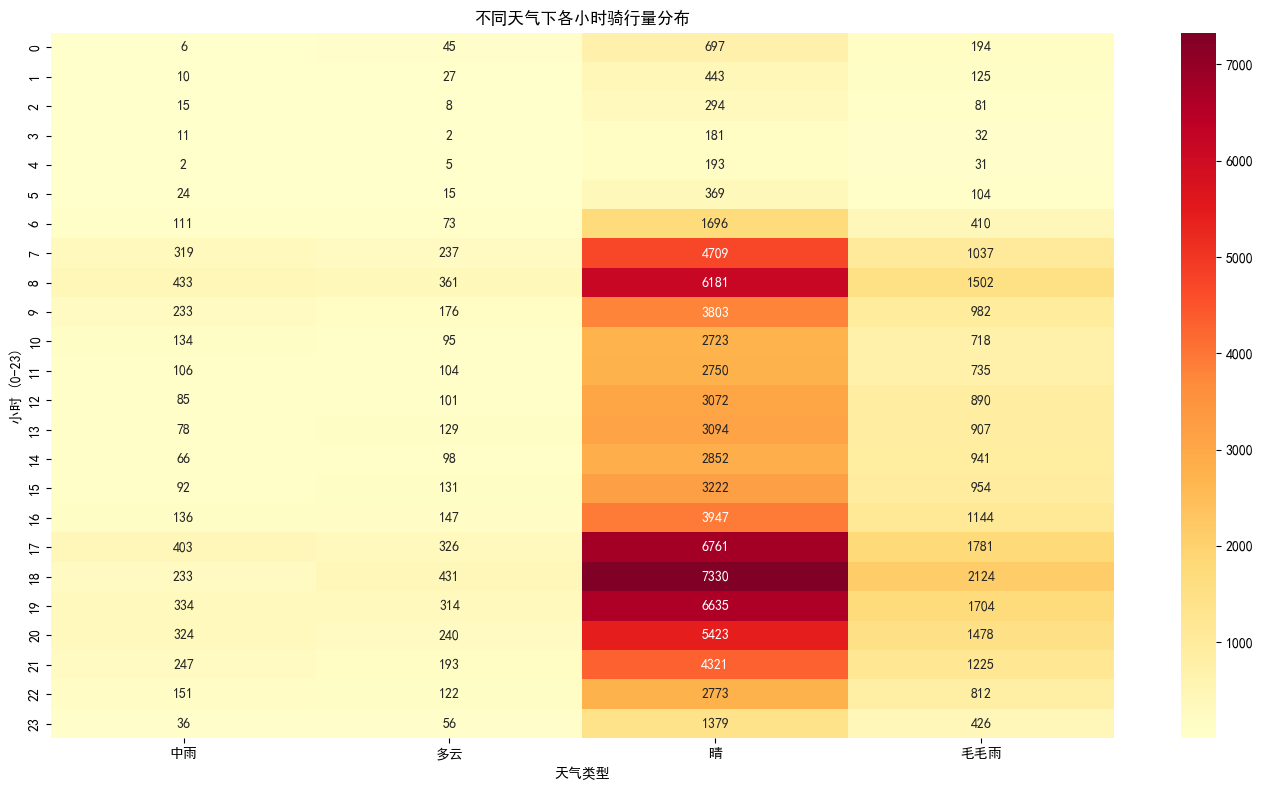

In [35]:
# 创建透视表：行=小时(start_hour)，列=天气，值=订单数
hour_weather_pivot = df.pivot_table(
    index='start_hour(h)',
    columns='天气',
    aggfunc='size',
    fill_value=0
)

# 绘制热力图
plt.figure(figsize=(14,8))
sns.heatmap(hour_weather_pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('不同天气下各小时骑行量分布')
plt.xlabel('天气类型')
plt.ylabel('小时 (0-23)')
plt.tight_layout()
plt.show()

##B4 空间分布分析

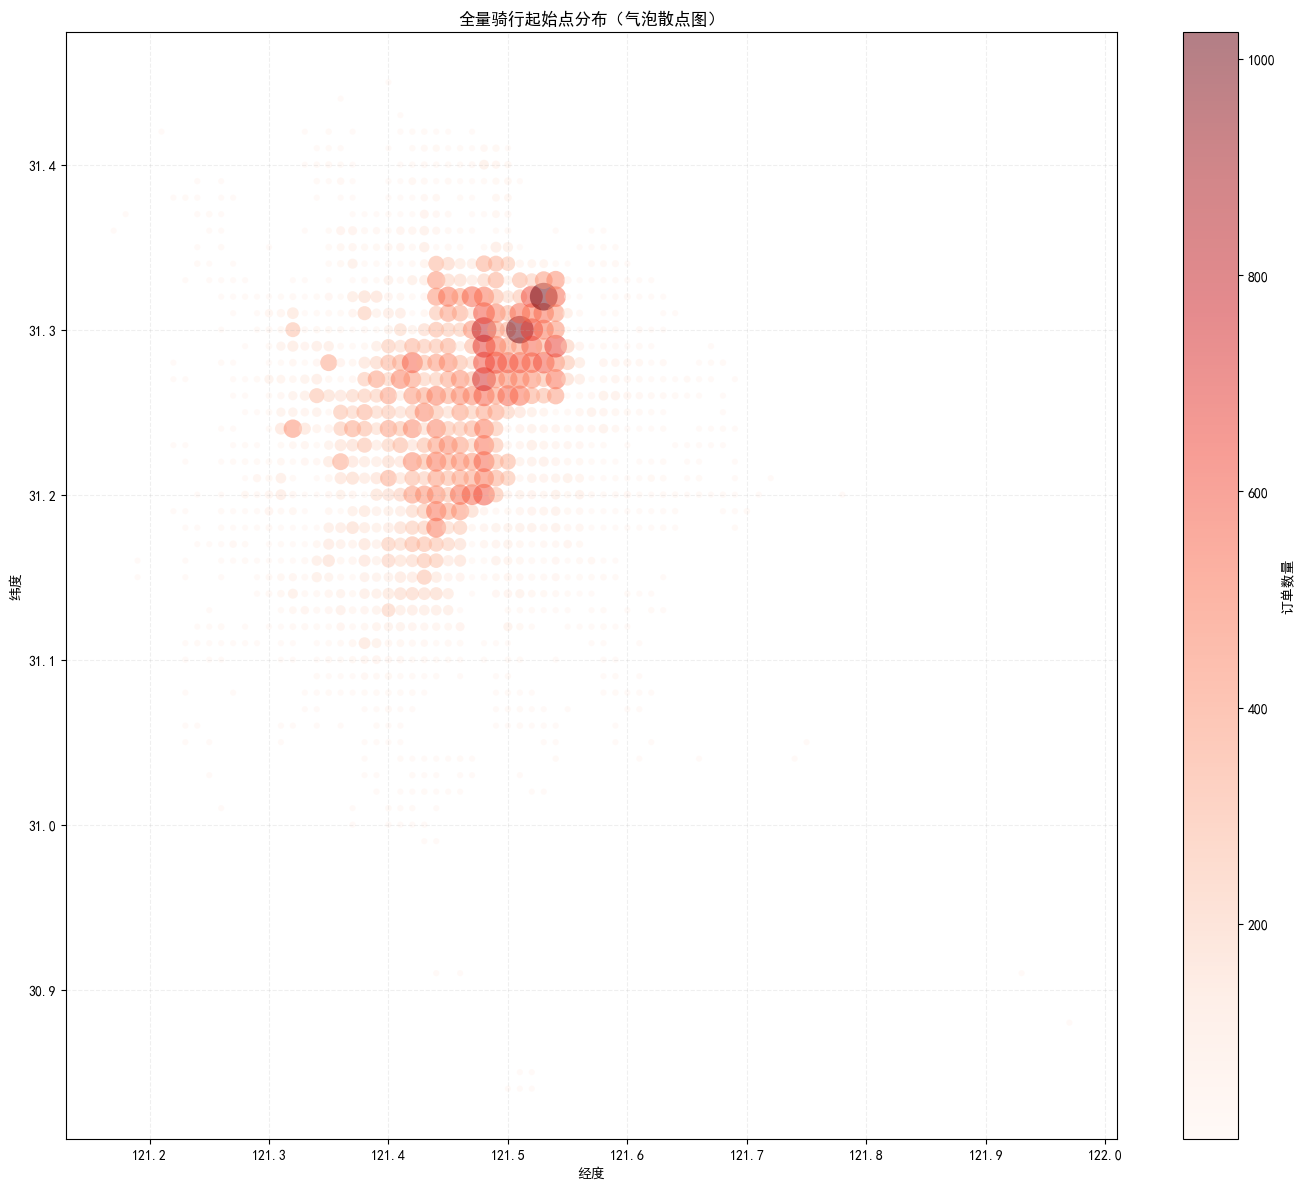

订单量最多的5个起始点：
     start_lon_round  start_lat_round  count
895           121.53            31.32   1025
836           121.51            31.30   1010
731           121.48            31.30    809
728           121.48            31.27    746
730           121.48            31.29    681


In [44]:
# 对起始经纬度进行分组聚合，统计每个位置点的订单数量
# 保留小数点后2位作为近似位置
df['start_lat_round'] = df['start_location_y(°)'].round(2)
df['start_lon_round'] = df['start_location_x(°)'].round(2)

# 统计每个位置点的骑行量（全部点）
start_points = df.groupby(['start_lon_round', 'start_lat_round']).size().reset_index(name='count')

# 绘制气泡散点图（全部点）
plt.figure(figsize=(14,12))


scatter = plt.scatter(
    start_points['start_lon_round'], 
    start_points['start_lat_round'],
    s=sizes,
    c=start_points['count'],
    alpha=0.5,          # 降低透明度，观察重叠区域
    cmap='Reds',
    edgecolors='none',  # 去掉边框，减少视觉干扰
)

cbar = plt.colorbar(scatter, label='订单数量')
cbar.ax.tick_params(labelsize=10)

plt.title('全量骑行起始点分布（气泡散点图）')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

# 输出订单量最多的5个起始点（用于了解热点）
print("骑行量最多的5个起始点：")
print(start_points.nlargest(5, 'count'))